In [1]:
"""
Example: Automatic config loading with ESN_model
"""
import numpy as np
from config.esn_config import auto_load_or_create, save_esn_config, find_matching_config, ESNConfig
from models_data_driven import ESN_model


# ========== Method 1: Using auto_load_or_create (Recommended) ==========
print("=" * 60)
print("Method 1: Using auto_load_or_create")
print("=" * 60)

t = np.linspace(0, 10, 1000)
data = np.sin(t)[np.newaxis, :, np.newaxis]

# First run: trains new model
print("\n>>> First call (will train):")
esn1 = auto_load_or_create(
    data=data,
    dt=0.01,
    N_units=20,
    config_dir="./saved_configs",
    auto_save=True,
    plot_training=False
)

# Second run: loads existing model (fast!)
print("\n>>> Second call (will load from cache):")
esn2 = auto_load_or_create(
    data=data,
    dt=0.01,
    N_units=20,
    config_dir="./saved_configs",
    auto_save=True,
    plot_training=False
)




Method 1: Using auto_load_or_create

>>> First call (will train):
Searching for config with hash: 17b06b7904ef6c26...
Searching for matching config... ./saved_configs and hash 17b06b7904ef6c26
✓ Found matching config: saved_configs/esn_17b06b7904ef6c26
Configuration loaded from saved_configs/esn_17b06b7904ef6c26
Loading pre-trained ESN_model...

>>> Second call (will load from cache):
Searching for config with hash: 17b06b7904ef6c26...
Searching for matching config... ./saved_configs and hash 17b06b7904ef6c26
✓ Found matching config: saved_configs/esn_17b06b7904ef6c26
Configuration loaded from saved_configs/esn_17b06b7904ef6c26
Loading pre-trained ESN_model...


In [2]:

# Verify they're the same
print(f"\n✓ Both models identical:  {np.allclose(esn1.Wout, esn2.Wout)}")
print(f"\n✓ Both models identical:  {np.allclose(esn1.W.toarray(), esn2.W.toarray())}")
print(f"\n✓ Both models identical:  {np.allclose(esn1.Win.toarray(), esn2.Win.toarray())}")
# print(f"\n✓ Both models identical:  {np.allclose(esn1.reservoir_state, esn2.reservoir_state)}")
print(f"\n✓ Both models identical:  {np.allclose(esn1.seed, esn2.seed)}")



✓ Both models identical:  True

✓ Both models identical:  True

✓ Both models identical:  True

✓ Both models identical:  True


In [3]:
esn1.seed

0

In [4]:

psi1, _ = esn1.time_integrate(Nt=100)  # Just to show no errors occur
psi2, _ = esn2.time_integrate(Nt=100)  # Just to show no errors occur

In [5]:
psi1.shape, psi2.shape

((100, 21, 1), (100, 21, 1))

In [6]:

print(f"Predictions identical: {np.allclose(psi1, psi2)}")

Predictions identical: True


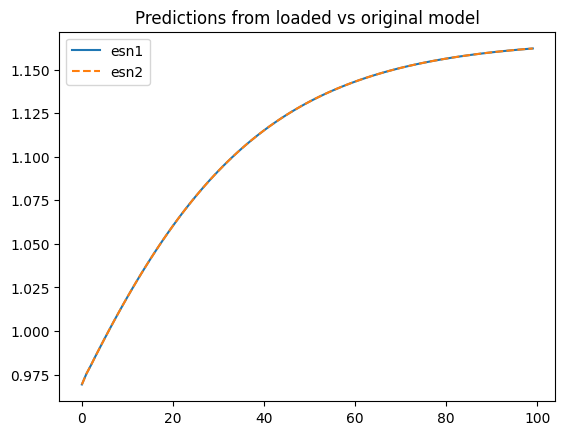

In [7]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(psi1[:, 0, 0], label='esn1')
plt.plot(psi2[:, 0, 0], '--', label='esn2')
plt.legend()
plt.title('Predictions from loaded vs original model')
plt.show()

In [8]:


# ========== Method 2: Manual config management ==========
print("\n" + "=" * 60)
print("Method 2: Manual config management")
print("=" * 60)

# Check if config exists
init_params = {
    'data': data,
    'dt': 0.01,
    'N_units':  50,
    'rho': 0.6,
    'sigma_in': 1.5,
}


query_config = ESNConfig.from_init_params(**init_params)
query_hash = query_config.to_hash()


matching_path = find_matching_config("./saved_configs", "esn_" + query_hash)

if matching_path:
    print(f"\n>>> Found existing config at: {matching_path}")
    config = ESNConfig.load_complete(matching_path)
    esn3 = config.to_esn_model(data=data)
    print("✓ Model loaded successfully")
else:
    print("\n>>> No matching config, training new model...")
    
    esn3 = ESN_model(data=data, dt=0.01, N_units=50, rho=0.6, 
                     sigma_in=1.5, plot_training=False)
    save_esn_config(esn3, save_dir="./saved_configs", name="esn_" + query_hash)




Method 2: Manual config management
Configuration loaded from saved_configs/esn_96511171a625c33c
Checking saved_configs/esn_96511171a625c33c: saved hash = 89b37180d5074321
Configuration loaded from saved_configs/esn_3d854a129e29a431
Checking saved_configs/esn_3d854a129e29a431: saved hash = 15908c68b1d029f2
Configuration loaded from saved_configs/esn_17b06b7904ef6c26
Checking saved_configs/esn_17b06b7904ef6c26: saved hash = 5abf62803f1a3cec
✗ No matching config found

>>> No matching config, training new model...
Training ESN model...


seed 0 	 Optimal hyperparameters: [0.5423770084746969, 1.1942018396712153], 1e-09, MSE: -0.8296495238957213
Configuration saved to saved_configs/esn_fd1f269187c95c3b
Trained data saved to saved_configs/esn_fd1f269187c95c3b/trained_data.npz
✓ Saved ESN config:  esn_fd1f269187c95c3b


In [9]:

# ========== Method 4: List all saved configs ==========
print("\n" + "=" * 60)
print("Method 4: List all saved configs")
print("=" * 60)

from config.esn_config import list_saved_configs

configs = list_saved_configs("./saved_configs", verbose=True)
print(f"\n✓ Total configs found: {len(configs)}")




Method 4: List all saved configs
Configuration loaded from saved_configs/esn_17b06b7904ef6c26

esn_17b06b7904ef6c26:
  Path: saved_configs/esn_17b06b7904ef6c26
  N_units: 20
  N_dim: 1
  dt:  0.01
Configuration loaded from saved_configs/esn_3d854a129e29a431

esn_3d854a129e29a431:
  Path: saved_configs/esn_3d854a129e29a431
  N_units: 20
  N_dim: 1
  dt:  0.01
Configuration loaded from saved_configs/esn_96511171a625c33c

esn_96511171a625c33c:
  Path: saved_configs/esn_96511171a625c33c
  N_units: 50
  N_dim: 1
  dt:  0.01
Configuration loaded from saved_configs/esn_fd1f269187c95c3b

esn_fd1f269187c95c3b:
  Path: saved_configs/esn_fd1f269187c95c3b
  N_units: 50
  N_dim: 1
  dt:  0.01

✓ Total configs found: 4


In [10]:
configs

[{'directory': PosixPath('saved_configs/esn_17b06b7904ef6c26'),
  'name': 'esn_17b06b7904ef6c26',
  'N_units': 20,
  'dt': 0.01,
  'training_data_filename': None},
 {'directory': PosixPath('saved_configs/esn_3d854a129e29a431'),
  'name': 'esn_3d854a129e29a431',
  'N_units': 20,
  'dt': 0.01,
  'training_data_filename': None},
 {'directory': PosixPath('saved_configs/esn_96511171a625c33c'),
  'name': 'esn_96511171a625c33c',
  'N_units': 50,
  'dt': 0.01,
  'training_data_filename': None},
 {'directory': PosixPath('saved_configs/esn_fd1f269187c95c3b'),
  'name': 'esn_fd1f269187c95c3b',
  'N_units': 50,
  'dt': 0.01,
  'training_data_filename': None}]